### Explanatory Data Analysis

* Author: Gina Nguyen

* Date: 03/05/2026

* Purpose: Explore the fincinal complaint dataset and extract any pattern or insights

In [197]:
# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy import stats

# Sklearn
from sklearn.model_selection import train_test_split

# Display
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

# 1. Overal exploration

In [198]:
import os
import duckdb

# Robust DuckDB path resolution: walk up to 4 levels and look for database/cfpb_complaints.duckdb
cwd = os.getcwd()
search_bases = []
base = cwd
db_path = None
for _ in range(4):
    search_bases.append(base)
    candidate = os.path.join(base, "database", "cfpb_complaints.duckdb")
    if os.path.exists(candidate):
        db_path = candidate
        break
    parent = os.path.dirname(base)
    if parent == base:
        break
    base = parent

if not db_path:
    raise FileNotFoundError(
        "DuckDB not found. Looked under these bases: " + ", ".join(search_bases)
    )

conn = duckdb.connect(db_path, read_only=True)
print(f"Connected to {db_path}")

Connected to /Users/ninhgiangnguyen/local_warehouse_pipeline/database/cfpb_complaints.duckdb


### 1.1 Head check 

In [199]:
# 1.1 Head check – basic preview

# Use the marts fact table as the main EDA source
df = conn.execute("""
    SELECT *
    FROM marts.fct_complaints
""").df()

row_count = conn.execute("""
    SELECT COUNT(*) AS n_rows
    FROM marts.fct_complaints
""").df()

print("Rows in marts.fct_complaints:")
print(row_count)
print("\nSample rows:")
df.iloc[:5]

Rows in marts.fct_complaints:
   n_rows
0  415254

Sample rows:


,complaint_id,product,sub_product,issue,sub_issue,company,state,zip_code,submitted_via,company_response,company_public_response,date_received,date_sent_to_company,complaint_year,complaint_month,complaint_month_date,days_to_response,is_timely_response,is_disputed,has_narrative,consumer_consent_provided,complaint_what_happened,tags
0,10000604,Credit card,General-purpose credit card or charge card,Problem with a purchase shown on your statement,Credit card company isn't resolving a dispute ...,JPMORGAN CHASE & CO.,MA,027XX,Web,Closed with explanation,None,2024-09-03,2024-09-03,2024,9,2024-09-01,0,True,<NA>,True,Consent provided,This situation has been going on since my XXXX...,"Older American, Servicemember"
1,10001246,"Money transfer, virtual currency, or money ser...",Mobile or digital wallet,Unauthorized transactions or other transaction...,None,JPMORGAN CHASE & CO.,IL,60616,Web,Closed with explanation,None,2024-09-03,2024-09-03,2024,9,2024-09-01,0,True,<NA>,True,Consent not provided,,Servicemember
2,10001329,Credit card,General-purpose credit card or charge card,Trouble using your card,Can't use card to make purchases,JPMORGAN CHASE & CO.,CA,XXXXX,Web,Closed with explanation,None,2024-09-03,2024-09-03,2024,9,2024-09-01,0,True,<NA>,True,Consent provided,On XX/XX/year> I contacted JPMC customer servi...,None
3,10003425,Checking or savings account,Checking account,Closing an account,Company closed your account,JPMORGAN CHASE & CO.,IL,60605,Web,Closed with explanation,None,2024-09-03,2024-09-03,2024,9,2024-09-01,0,True,<NA>,True,Consent provided,"On Saturday, XX/XX/XXXX, at approximately XXXX...",None
4,10016270,Checking or savings account,Checking account,Managing an account,Deposits and withdrawals,JPMORGAN CHASE & CO.,IN,46304,Referral,Closed with explanation,None,2024-09-05,2024-09-05,2024,9,2024-09-01,0,True,<NA>,True,N/A,,None


### 1.2 Column type

In [200]:
# 1.2 Column type – dtypes + high-level summary
print("Data types (from pandas):")
print(df.dtypes.to_frame("dtype"))

Data types (from pandas):
                                    dtype
complaint_id                       object
product                            object
sub_product                        object
issue                              object
sub_issue                          object
company                            object
state                              object
zip_code                           object
submitted_via                      object
company_response                   object
company_public_response            object
date_received              datetime64[us]
date_sent_to_company       datetime64[us]
complaint_year                      int64
complaint_month                     int64
complaint_month_date       datetime64[us]
days_to_response                    int64
is_timely_response                   bool
is_disputed                       boolean
has_narrative                        bool
consumer_consent_provided          object
complaint_what_happened            object
tags    

In [201]:
summary = df.describe(include="all")
print("\nSummary statistics:")
summary


Summary statistics:


,complaint_id,product,sub_product,issue,sub_issue,company,state,zip_code,submitted_via,company_response,company_public_response,date_received,date_sent_to_company,complaint_year,complaint_month,complaint_month_date,days_to_response,is_timely_response,is_disputed,has_narrative,consumer_consent_provided,complaint_what_happened,tags
count,415254,415254,415251,415251,388450,415254,412584,415227,415254,415253,201660,415254,415254,415254.000000,415254.000000,415254,415254.000000,415254,0,415254,389128,415254,60043
unique,415254,14,58,90,208,68,61,17979,5,5,9,NaN,NaN,NaN,NaN,NaN,NaN,2,0,1,5,190898,3
top,10000604,Checking or savings account,General-purpose credit card or charge card,Managing an account,Deposits and withdrawals,CAPITAL ONE FINANCIAL CORPORATION,CA,XXXXX,Web,Closed with explanation,Company has responded to the consumer and the ...,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,True,Consent provided,,Older American
freq,1,120474,103850,70702,26913,75862,61156,14031,379056,306974,201473,NaN,NaN,NaN,NaN,NaN,NaN,414229,NaN,415254,196237,219064,27626
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-09-20 23:11:21.466283,2024-09-22 00:46:17.257293,2024.248963,6.208718,2024-09-06 06:50:01.447789,1.065924,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-01-01 00:00:00,2023-01-01 00:00:00,2023.000000,1.000000,2023-01-01 00:00:00,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-12-16 00:00:00,2023-12-17 00:00:00,2023.000000,3.000000,2023-12-01 00:00:00,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-11-02 00:00:00,2024-11-03 00:00:00,2024.000000,6.000000,2024-11-01 00:00:00,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-07-10 00:00:00,2025-07-11 00:00:00,2025.000000,9.000000,2025-07-01 00:00:00,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-02-26 00:00:00,2026-02-26 00:00:00,2026.000000,12.000000,2026-02-01 00:00:00,408.000000,NaN,NaN,NaN,NaN,NaN,NaN


### 1.3 Categorize columns

* Manullay recategorize the columns based on the domain knowledge

In [202]:
# 1.3 Categorize columns – id / dates / categorical / numeric / text

all_cols = [c[1] for c in conn.execute(
    "PRAGMA table_info('marts.fct_complaints')"
).fetchall()]

id_cols = ["complaint_id"]

date_cols = [
    "date_received",
    "date_sent_to_company",
    "complaint_month_date",
]

bool_cols = [
    "is_timely_response",
    "is_disputed",
    "has_narrative",
]

categorical_cols = [
    "product",
    "sub_product",
    "issue",
    "sub_issue",
    "company",
    "state",
    "zip_code",
    "submitted_via",
    "company_response",
    "company_public_response",
    "consumer_consent_provided",
    "tags",
    "complaint_year",
    "complaint_month",
]

numeric_cols = [
    "days_to_response",

]

text_cols = [
    "complaint_what_happened",
]

print("Column groups for analysis:")
print("- ID:", id_cols)
print("- Dates:", date_cols)
print("- Boolean flags:", bool_cols)
print("- Categorical:", categorical_cols)
print("- Numeric:", numeric_cols)
print("- Text:", text_cols)

Column groups for analysis:
- ID: ['complaint_id']
- Dates: ['date_received', 'date_sent_to_company', 'complaint_month_date']
- Boolean flags: ['is_timely_response', 'is_disputed', 'has_narrative']
- Categorical: ['product', 'sub_product', 'issue', 'sub_issue', 'company', 'state', 'zip_code', 'submitted_via', 'company_response', 'company_public_response', 'consumer_consent_provided', 'tags', 'complaint_year', 'complaint_month']
- Numeric: ['days_to_response']
- Text: ['complaint_what_happened']


In [203]:
# Quick cardinality check for categorical columns
cardinality = conn.execute(
    """
    SELECT
        'product' AS col, COUNT(DISTINCT product) AS distinct_values FROM marts.fct_complaints
    UNION ALL SELECT 'sub_product', COUNT(DISTINCT sub_product) FROM marts.fct_complaints
    UNION ALL SELECT 'issue', COUNT(DISTINCT issue) FROM marts.fct_complaints
    UNION ALL SELECT 'sub_issue', COUNT(DISTINCT sub_issue) FROM marts.fct_complaints
    UNION ALL SELECT 'company', COUNT(DISTINCT company) FROM marts.fct_complaints
    UNION ALL SELECT 'state', COUNT(DISTINCT state) FROM marts.fct_complaints
    """
).df()

print("\nCategorical cardinality (selected columns):")
cardinality


Categorical cardinality (selected columns):


,col,distinct_values
0,product,14
1,sub_product,58
2,issue,90
3,sub_issue,208
4,company,68
5,state,61


# 2. Clean problematic data

### 2.1 Rename column

In [204]:
# Standardize: strip whitespace, lowercase, replace spaces/dashes with underscore
def rename_column(sample_df): 
    df = sample_df.copy()
    old_cols = df.columns.tolist()
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(r'[\s\-]+', '_', regex=True)
        .str.replace(r'[^a-z0-9_]', '', regex=True)
    )

    rename_map = {o: n for o, n in zip(old_cols, df.columns.tolist()) if o != n}
    if rename_map:
        print("Renamed columns:")
        for o, n in rename_map.items():
            print(f"  '{o}' → '{n}'")
        
        df.columns.tolist()
        
    else:
        print("No column renames needed — already consistent")

In [205]:
rename_column(df)

No column renames needed — already consistent


### 2.2 Standadize data

In [206]:
# Normalize all string categoricals to title case for consistency
def standardize_categorical_data(df, categorical_cols):
    num_cols_cleaned = 0 
    for col in categorical_cols:
        if col in df.columns and df[col].dtype == object:
            before = df[col].nunique(dropna=True)
            df[col] = df[col].str.strip().str.title()
            after = df[col].nunique(dropna=True)
            if before != after:
                print(f"  {col}: {before} to {after} distinct values (case-folding merged some)")
                num_cols_cleaned += 1 
    if num_cols_cleaned == 0:
        print("All categorical columns are already standard")
    else:
        print(f"Standardized {num_cols_cleaned} categorical columns ! Categorical variable standardization done !")

In [207]:
standardize_categorical_data(df, categorical_cols)

All categorical columns are already standard


### 2.3 Clean duplication

##### 2.3.1 Analyze duplication 

In [208]:
n_before = len(df)

# Full-row duplicates
n_full_dups = df.duplicated().sum()
print(f"Full-row duplicates   : {n_full_dups}")

# Duplicate complaint_ids
if 'complaint_id' in df.columns:
    n_id_dups = df.duplicated(subset=['complaint_id']).sum()
    print(f"Duplicate complaint_id: {n_id_dups}")

Full-row duplicates   : 0
Duplicate complaint_id: 0


##### 2.3.2 Drop duplication

In [209]:
# Drop full-row duplicates, keep first

def drop_duplication(df):
    # For full-row duplicates
    df = df.drop_duplicates()

    # For IDs duplicate, keep the most recent record
    if 'complaint_id' in df.columns and 'date_received' in all_cols:
        df = (
            df.sort_values('date_received', ascending=False)
            .drop_duplicates(subset=['complaint_id'], keep='first')
        )
    print(f"\nRows before: {n_before:,}  →  after dedup: {len(df):,}  (removed {n_before - len(df):,})")

* Since There is no full row duplicates nor duplicate ids, then no need to execute the function here

### 2.4 Clean dtype

In [210]:
def clean_dtype(df, date_cols=None, bool_cols=None, numeric_cols=None, categorical_cols=None):      # update later if there are more dtype of value
    # Dates 
    if date_cols:
        for col in date_cols:
            if col in df.columns:
                df[col] = pd.to_datetime(df[col], errors='coerce')

    # Booleans 
    if bool_cols:
        bool_map = {'yes': True, 'no': False, '1': True, '0': False,
                    'true': True, 'false': False, 'y': True, 'n': False}
        for col in bool_cols:
            if col in df.columns:
                if df[col].dtype == object:
                    df[col] = df[col].str.strip().str.lower().map(bool_map)
                df[col] = df[col].astype('boolean')

    # Numeric
    if numeric_cols:
        for col in numeric_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')

    # Categorical strings: strip whitespace 
    if categorical_cols:
        for col in categorical_cols:
            if col in df.columns and df[col].dtype == object:
                df[col] = df[col].str.strip()

    print("\n=== Updated dtypes ===")
    print(df.dtypes)

In [211]:
clean_dtype(df, date_cols, bool_cols, numeric_cols, categorical_cols)


=== Updated dtypes ===
complaint_id                         object
product                              object
sub_product                          object
issue                                object
sub_issue                            object
company                              object
state                                object
zip_code                             object
submitted_via                        object
company_response                     object
company_public_response              object
date_received                datetime64[us]
date_sent_to_company         datetime64[us]
complaint_year                        int64
complaint_month                       int64
complaint_month_date         datetime64[us]
days_to_response                      int64
is_timely_response                  boolean
is_disputed                         boolean
has_narrative                       boolean
consumer_consent_provided            object
complaint_what_happened              object
tags    

# 3. Null & Outlier analysis

### 3.1 Null rate analysis

##### 3.1.1 Null rate 

In [212]:
def null_analysis(df,
                labels=['0%', '1–20%', '20–50%', '50–80%', '80–90%', '90–95%', '>95%'], 
                thresh_list=[80, 90, 95]):
    null_df = pd.DataFrame({
        'null_count': df.isnull().sum(),
        'null_pct':   round(df.isnull().mean() * 100, 2)
    }).sort_values('null_pct', ascending=False)
    print("=== Null Rate Summary ===")
    print(null_df.to_string())

    print("\n=== Columns above key thresholds ===")
    for thresh in thresh_list:
        cols_above = null_df[null_df['null_pct'] >= thresh].index.tolist()
        print(f"  ≥{thresh}% null: {cols_above if cols_above else 'none'}")

In [213]:
null_analysis(df)

=== Null Rate Summary ===
                           null_count  null_pct
is_disputed                    415254    100.00
tags                           355211     85.54
company_public_response        213594     51.44
sub_issue                       26804      6.45
consumer_consent_provided       26126      6.29
state                            2670      0.64
zip_code                           27      0.01
complaint_month                     0      0.00
complaint_what_happened             0      0.00
has_narrative                       0      0.00
is_timely_response                  0      0.00
days_to_response                    0      0.00
complaint_month_date                0      0.00
complaint_id                        0      0.00
complaint_year                      0      0.00
date_sent_to_company                0      0.00
product                             0      0.00
company_response                    1      0.00
submitted_via                       0      0.00
company       

##### 3.1.2 Null visualization

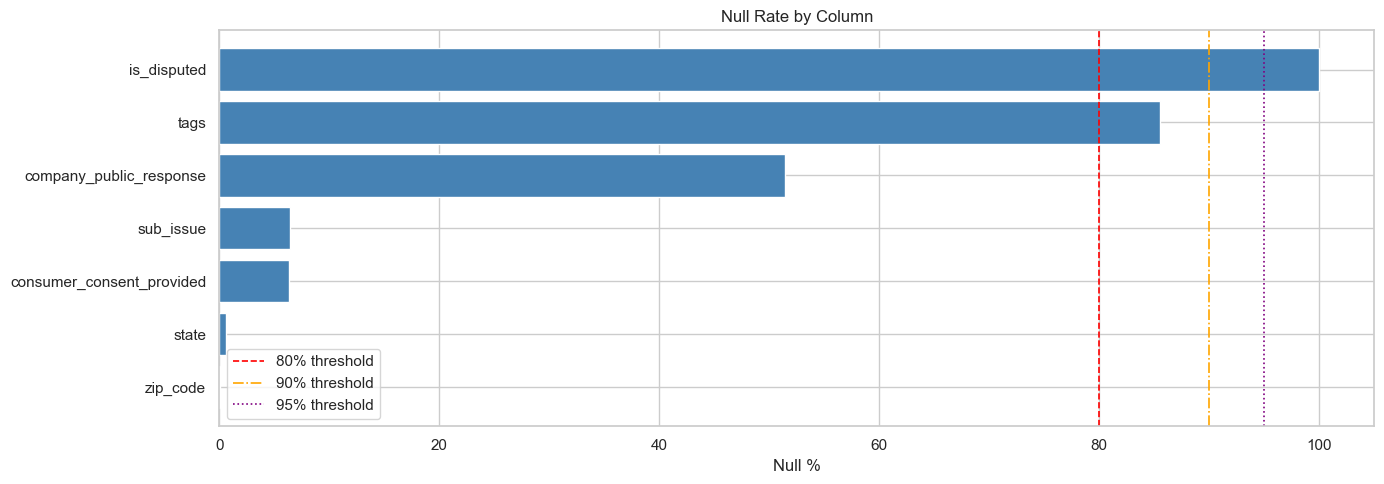

In [214]:
fig, ax = plt.subplots(figsize=(14, 5))
cols_with_nulls = null_df[null_df['null_pct'] > 0]
bars = ax.barh(cols_with_nulls.index, cols_with_nulls['null_pct'], color='steelblue')
for thresh, color, ls in [(80,'red','--'), (90,'orange','-.'), (95,'purple',':')]:
    ax.axvline(thresh, color=color, linestyle=ls, linewidth=1.2, label=f'{thresh}% threshold')
ax.set_xlabel('Null %')
ax.set_title('Null Rate by Column')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

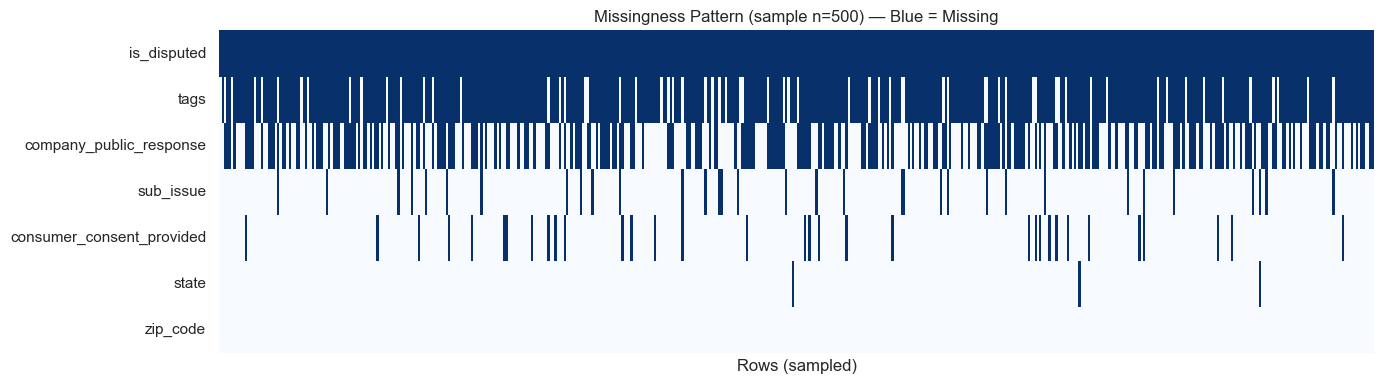

In [215]:
# Missingness pattern heatmap (sample for performance)
cols_any_null = null_df[null_df['null_pct'] > 0].index.tolist()

if cols_any_null:
    sample_size = min(500, len(df))
    sample_df = df[cols_any_null].sample(sample_size, random_state=42)
    miss_matrix = sample_df.isnull().astype(int)

    fig, ax = plt.subplots(figsize=(14, 4))
    sns.heatmap(miss_matrix.T, cmap='Blues', cbar=False,
                yticklabels=True, xticklabels=False, ax=ax)
    ax.set_title(f'Missingness Pattern (sample n={sample_size}) — Blue = Missing')
    ax.set_xlabel('Rows (sampled)')
    plt.tight_layout()
    plt.show()
else:
    print('No nulls found — missingness heatmap skipped')

##### 3.1.3 Categorize null types

* Classify null type for each high-null column (domain knowledge annotations)

| Column                     | Null Type       | Explanation |
|----------------------------|-----------------|-------------|
| sub_product                | Not applicable  | Not every product has a sub-product |
| sub_issue                  | Not applicable  | Not every issue has a sub-issue |
| company_public_response    | Unavailable     | Company may choose not to provide public response |
| consumer_consent_provided  | Unavailable     | Consumer may not have consented to share |
| tags                       | Not applicable  | Tags only populated for special cohorts (servicemember, older American);  `tags=N/A` rows expected to be null |
| complaint_what_happened    | Unavailable     | Consumer consent required; `has_narrative=False` rows expected to be null |
| zip_code                   | Unknown         | May not have been collected or entered |
| is_disputed                | Unknown         | Dispute flag may not be available for all cases |

* function here
* pick khong dung variable
* list of test 
* stdv = none

In [216]:
# MCAR / MAR / MNAR quick test: is null in sub_product correlated with product?

def missingness_correlation_tests(
    df,
    target_cols,
    top_k_categories=10
):
    """
    Test whether missingness of selected columns correlates with every other column.
    Helps determine MCAR vs MAR behavior.
    """

    print("=== Missingness Correlation Tests (MCAR vs MAR heuristic) ===\n")
    for target_col in target_cols:
        if target_col not in df.columns:
            continue
        print(f"\n--- Testing missingness of: {target_col} ---")
        is_null = df[target_col].isnull().astype(int)
        for predictor_col in df.columns:
            if predictor_col == target_col:
                continue
            predictor = df[predictor_col]

            try:
                # CATEGORICAL VARIABLES
                if predictor.dtype == "object" or predictor.dtype.name == "category" or predictor.dtype == "bool":
                    top = predictor.value_counts().head(top_k_categories).index
                    predictor_reduced = predictor.where(predictor.isin(top), other="_other_")
                    ct = pd.crosstab(is_null, predictor_reduced)
                    if ct.shape[0] > 1 and ct.shape[1] > 1:
                        chi2, p, dof, _ = stats.chi2_contingency(ct)
                        conclusion = ( "Likely MAR (not MCAR)" if p < 0.05 else "Cannot reject MCAR")
                        print(
                            f"{target_col:30s} | {predictor_col:25s} "
                            f"→ chi2={chi2:8.1f}, p={p:.4f} → {conclusion}"
                        )
                # NUMERIC VARIABLES
                else:
                    predictor_numeric = predictor.fillna(0).astype(float)
                    
                    # Skip if either series has zero variance (would cause divide-by-zero in corr)
                    if is_null.std() == 0 or predictor_numeric.std() == 0:
                        continue
                    
                    corr = is_null.corr(predictor_numeric)
                    conclusion = ("Likely MAR" if abs(corr) > 0.1 else "Possibly MCAR")
                    print(
                        f"{target_col:30s} | {predictor_col:25s} "
                        f"→ corr={corr:.3f} → {conclusion}"
                    )

            except Exception:
                # Skip problematic columns silently
                continue

In [217]:
missingness_correlation_tests(df, [
        'sub_product',
        'tags',
        'company_public_response',
        'sub_issue',
        'consumer_consent_provided'
    ])

=== Missingness Correlation Tests (MCAR vs MAR heuristic) ===


--- Testing missingness of: sub_product ---
sub_product                    | complaint_id              → chi2=     0.0, p=1.0000 → Cannot reject MCAR
sub_product                    | product                   → chi2=     7.3, p=0.6930 → Cannot reject MCAR
sub_product                    | issue                     → chi2=     6.8, p=0.7472 → Cannot reject MCAR
sub_product                    | sub_issue                 → chi2=     2.4, p=0.9926 → Cannot reject MCAR
sub_product                    | company                   → chi2=     9.2, p=0.5173 → Cannot reject MCAR
sub_product                    | state                     → chi2=     9.5, p=0.4899 → Cannot reject MCAR
sub_product                    | zip_code                  → chi2=     0.1, p=1.0000 → Cannot reject MCAR
sub_product                    | submitted_via             → chi2=    75.4, p=0.0000 → Likely MAR (not MCAR)
sub_product                    | company_

### 3.2 Outlier analysis

* func here
* histogram/normalization/bell chart check
* log normaliation: distribution before after to compare
* coplaint month, analysis or not for outlie r?

In [218]:
def outlier_analysis(df, numeric_cols): 
    outlier_summary = []
    for col in numeric_cols:
        s = df[col].dropna()
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = ((s < lo) | (s > hi)).sum()
        z = np.abs(stats.zscore(s))
        n_z = (z > 3).sum()
        outlier_summary.append({
            'column': col, 'mean': s.mean(), 'median': s.median(),
            'std': s.std(), 'min': s.min(), 'max': s.max(),
            'IQR_low': lo, 'IQR_high': hi,
            'n_IQR_outliers': n_out,
            'pct_IQR_outliers': round(n_out / len(s) * 100, 2),
            'n_zscore>3': n_z
        })

    outlier_df = pd.DataFrame(outlier_summary)
    print("=== Outlier Summary ===")
    return outlier_df

In [219]:
outlier_analysis(df, numeric_cols)

=== Outlier Summary ===


,column,mean,median,std,min,max,IQR_low,IQR_high,n_IQR_outliers,pct_IQR_outliers,n_zscore>3
0,days_to_response,1.065924,0.0,5.633016,0,408,0.0,0.0,41094,9.9,8623


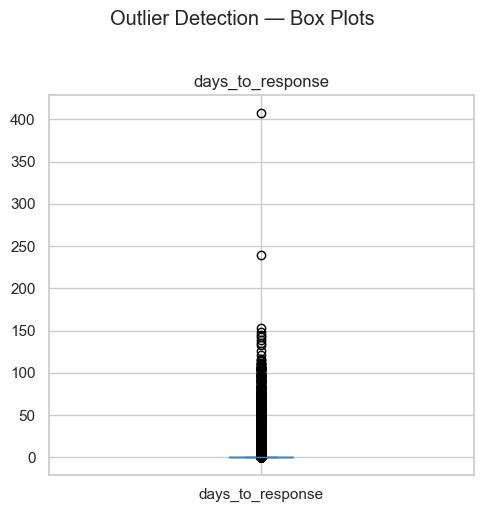

In [220]:
if numeric_cols:
    fig, axes = plt.subplots(1, len(numeric_cols), figsize=(5 * len(numeric_cols), 5))
    if len(numeric_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, numeric_cols):
        df[col].dropna().plot.box(ax=ax, color='steelblue')
        ax.set_title(col)
    plt.suptitle('Outlier Detection — Box Plots', y=1.02)
    plt.tight_layout()
    plt.show()

In [221]:
if 'days_to_response' in df.columns:
    s = df['days_to_response'].dropna()
    print("=== days_to_response outlier deep-dive ===")
    print(f"  Negative values (data error): {(s < 0).sum()}")
    print(f"  > 365 days (global outlier?): {(s > 365).sum()}")
    print(f"  > 60 days  (collective?):     {(s > 60).sum()}")
    print("\nTop 10 extreme values:")
    print(s.nlargest(10).to_frame())
    print("\nDomain note: CFPB requires response within 15 days. "
          "Values >60 days could be legitimate escalations or pipeline errors — investigate.")

=== days_to_response outlier deep-dive ===
  Negative values (data error): 0
  > 365 days (global outlier?): 1
  > 60 days  (collective?):     260

Top 10 extreme values:
        days_to_response
272859               408
82720                239
299754               153
90093                148
372786               145
304093               143
347925               139
21126                136
330130               133
273820               126

Domain note: CFPB requires response within 15 days. Values >60 days could be legitimate escalations or pipeline errors — investigate.


# 4 EDA

### 4.1 Univariate EDA 

##### 4.1.1 Binary variable EDA

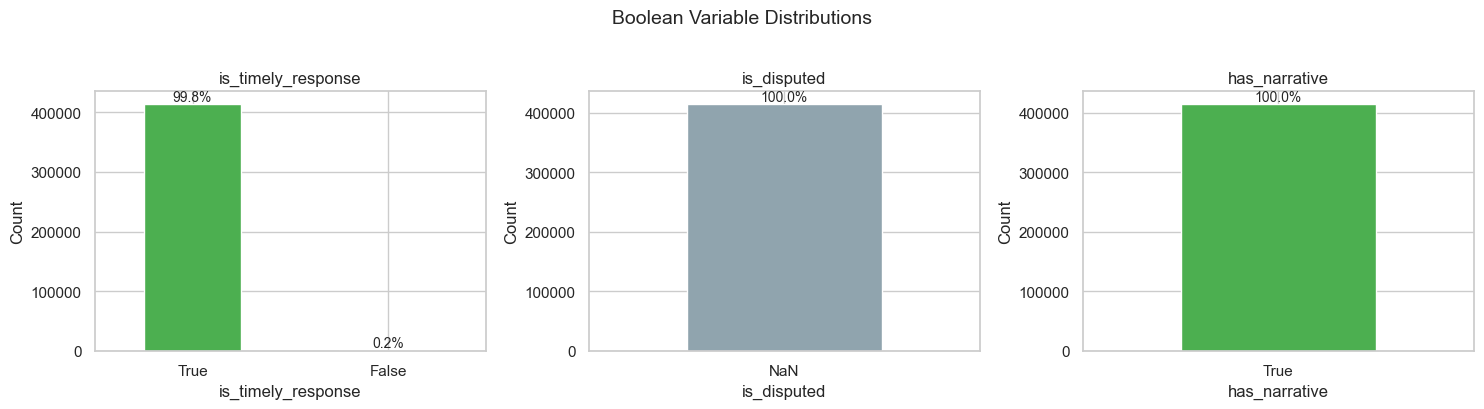

In [222]:
n = len(bool_cols)

fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
if n == 1: axes = [axes]

for ax, col in zip(axes, bool_cols):
    vc = df[col].value_counts(dropna=False).rename(index={True:'True', False:'False', pd.NA:'NaN', None:'NaN'})
    colors = ['#4CAF50' if str(i) == 'True' else '#EF5350' if str(i) == 'False' else '#90A4AE'
              for i in vc.index]
    vc.plot.bar(ax=ax, color=colors, edgecolor='white')
    ax.set_title(col)
    ax.set_ylabel('Count')
    ax.set_xticklabels(vc.index, rotation=0)
    total = vc.sum()
    for p in ax.patches:
        ax.annotate(f'{p.get_height()/total:.1%}',
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=10)

plt.suptitle('Boolean Variable Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

* As is_dispute and has_narrative both have 100% of single vlaue, then it doesn't have distinguish power, we are then safe to drop it 

##### 4.1.2 Categorical variable EDA

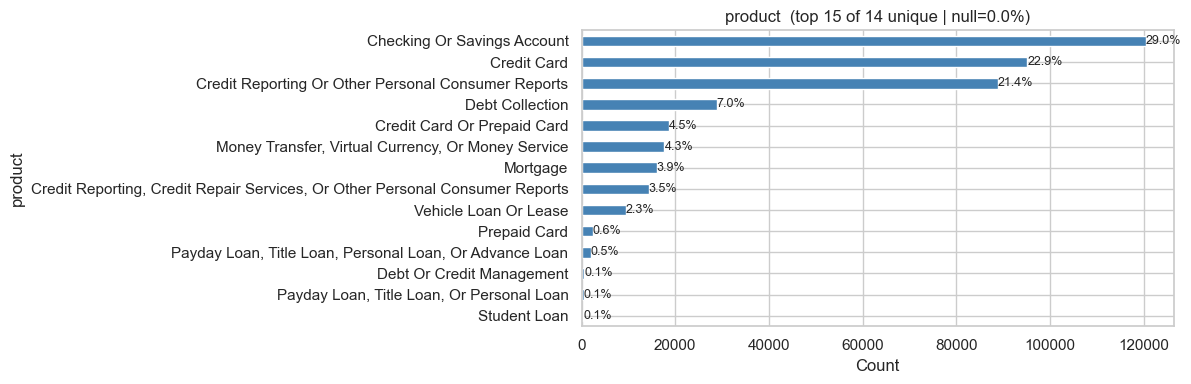

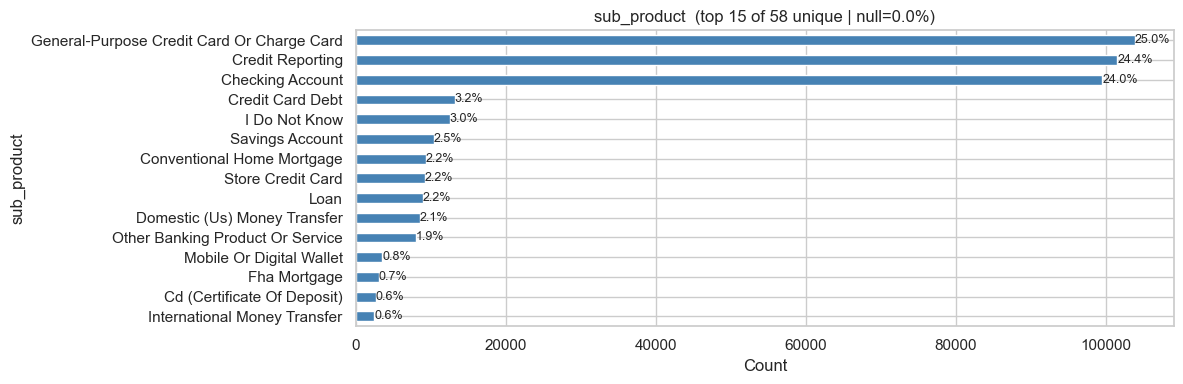

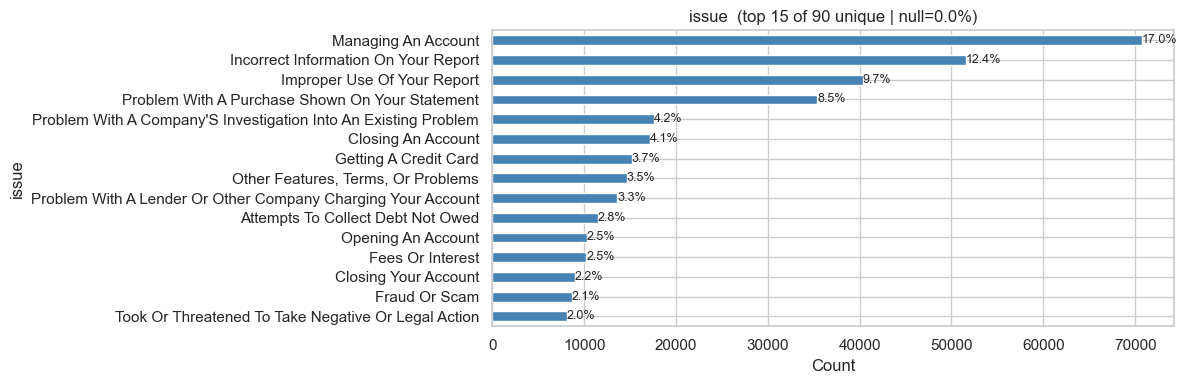

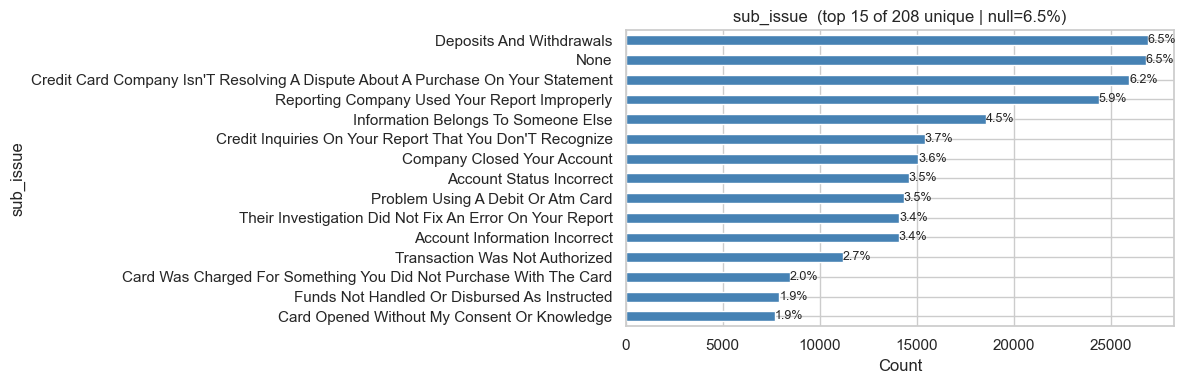

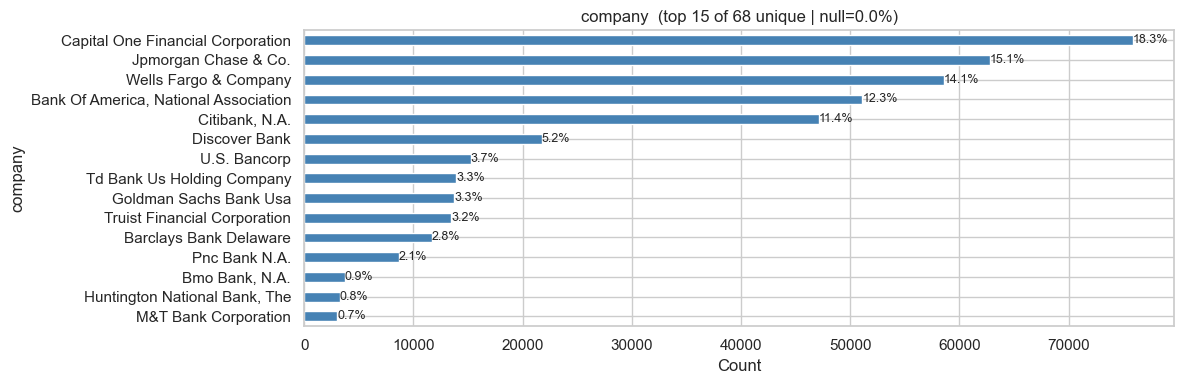

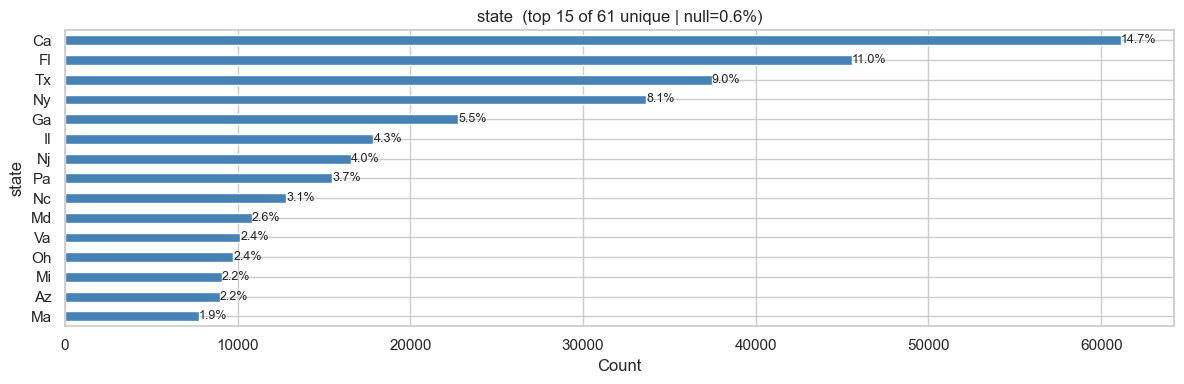

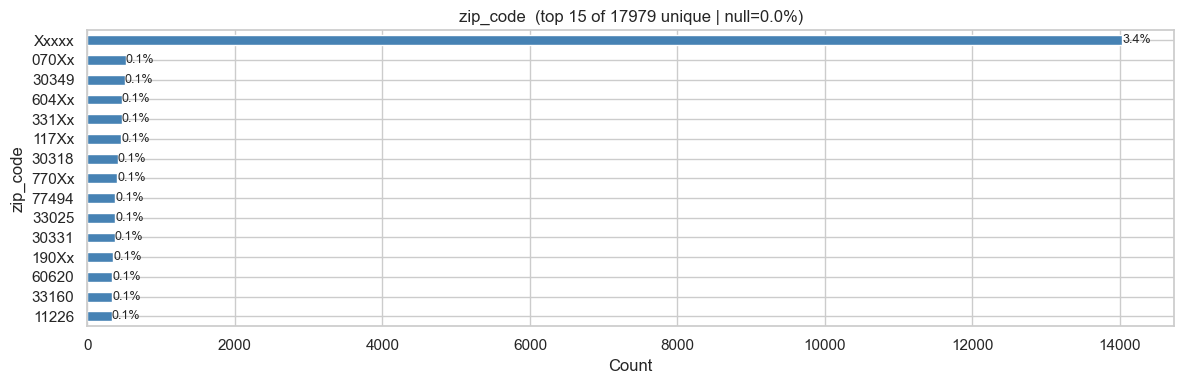

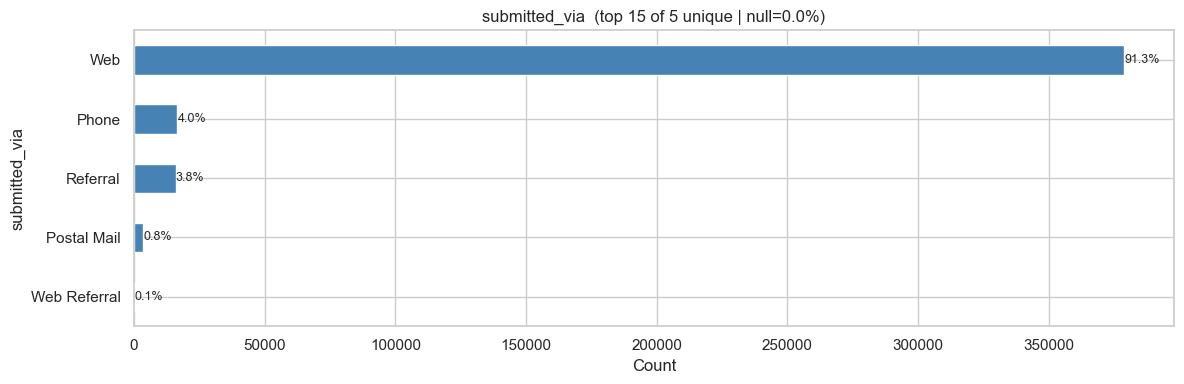

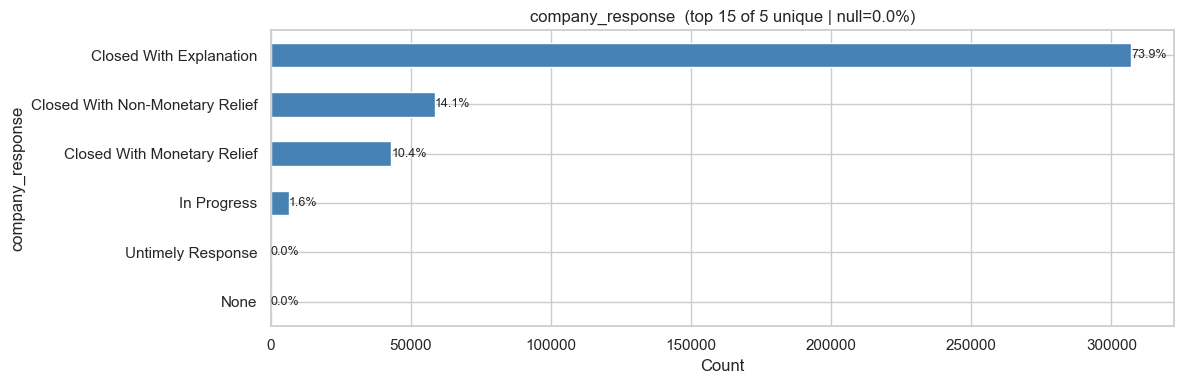

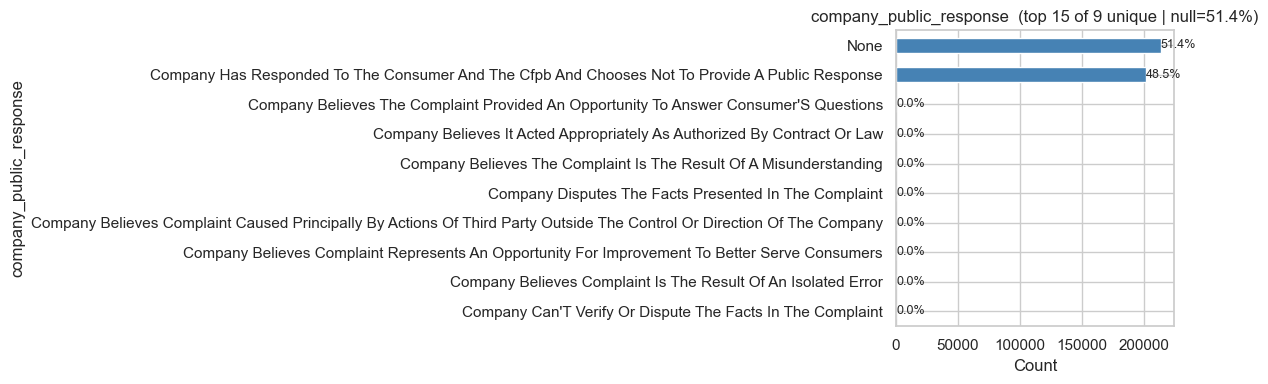

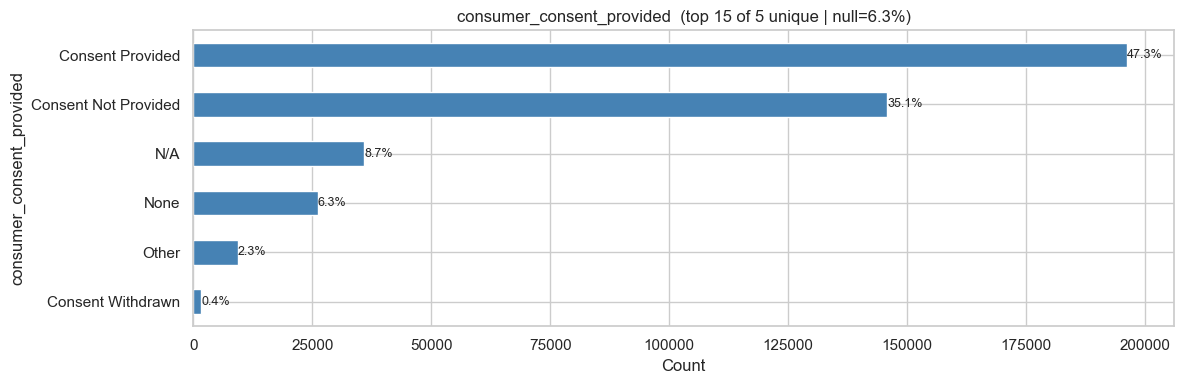

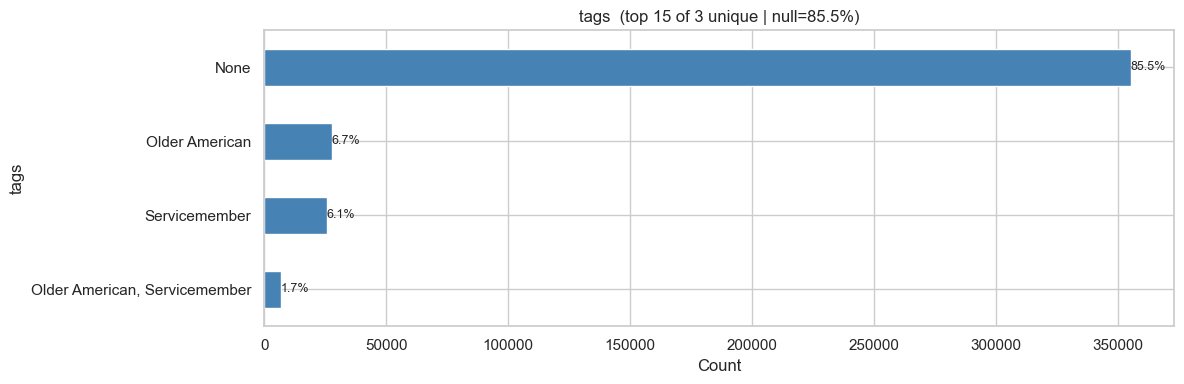

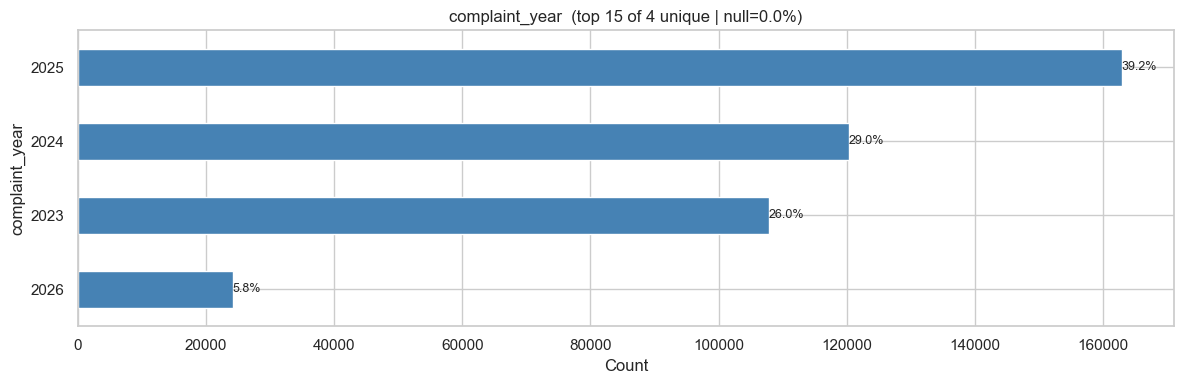

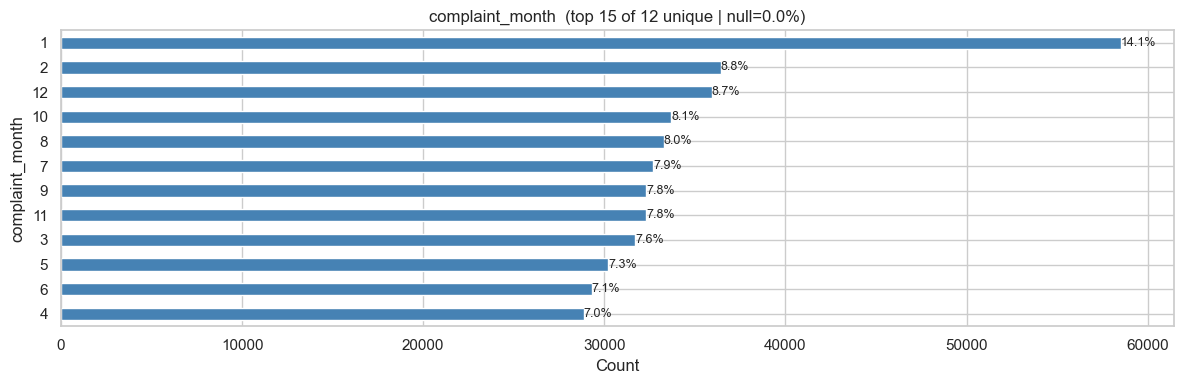

In [223]:
TOP_N = 15

for col in categorical_cols:
    vc = df[col].value_counts(dropna=False).head(TOP_N)
    fig, ax = plt.subplots(figsize=(12, 4))
    vc.plot.barh(ax=ax, color='steelblue', edgecolor='white')
    ax.invert_yaxis()
    ax.set_title(f'{col}  (top {TOP_N} of {df[col].nunique()} unique | null={df[col].isnull().mean():.1%})')
    ax.set_xlabel('Count')
    total = len(df)
    for p in ax.patches:
        ax.annotate(f'{p.get_width()/total:.1%}',
                    (p.get_width(), p.get_y() + p.get_height() / 2),
                    ha='left', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()

##### 4.1.3 Numeric variable distribution EDA

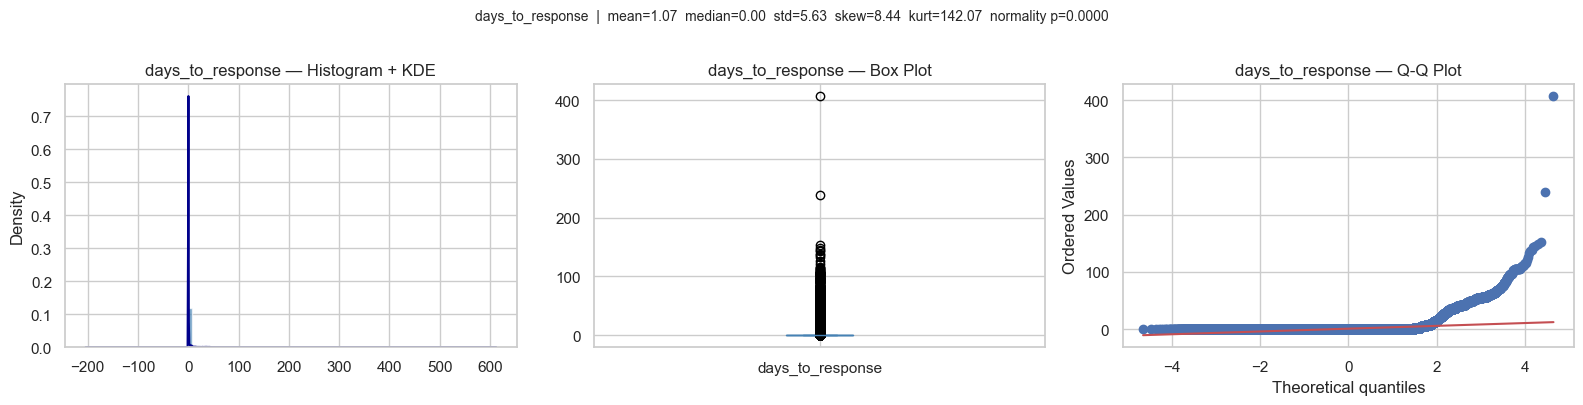

In [224]:
for col in numeric_cols:
    s = df[col].dropna()
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Histogram + KDE
    s.plot.hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white', density=True, alpha=0.7)
    s.plot.kde(ax=axes[0], color='darkblue')
    axes[0].set_title(f'{col} — Histogram + KDE')

    # Box plot
    s.plot.box(ax=axes[1], color='steelblue')
    axes[1].set_title(f'{col} — Box Plot')

    # Q-Q plot
    stats.probplot(s, dist='norm', plot=axes[2])
    axes[2].set_title(f'{col} — Q-Q Plot')

    # Stats annotation
    skew = s.skew()
    kurt = s.kurt()
    _, p_norm = stats.normaltest(s.sample(min(5000, len(s)), random_state=42))
    fig.suptitle(
        f'{col}  |  mean={s.mean():.2f}  median={s.median():.2f}  '
        f'std={s.std():.2f}  skew={skew:.2f}  kurt={kurt:.2f}  '
        f'normality p={p_norm:.4f}',
        fontsize=10, y=1.01
    )
    plt.tight_layout()
    plt.show()

### 4.2 Bi-variate EDA 

##### 4.2.1 Numeric bi-variate 

In [231]:
if len(numeric_cols) > 1:
    corr = df[numeric_cols].corr()
    fig, ax = plt.subplots(figsize=(7, 5))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, ax=ax, linewidths=0.5)
    ax.set_title('Numeric Feature Correlation Heatmap')
    plt.tight_layout()
    plt.show()
else:
    print('Need ≥2 numeric columns for correlation heatmap')

Need ≥2 numeric columns for correlation heatmap


##### 4.2.2 Categorical bi-variate 

In [ ]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(ct, correction=False)[0]
    n = ct.sum().sum()
    return np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

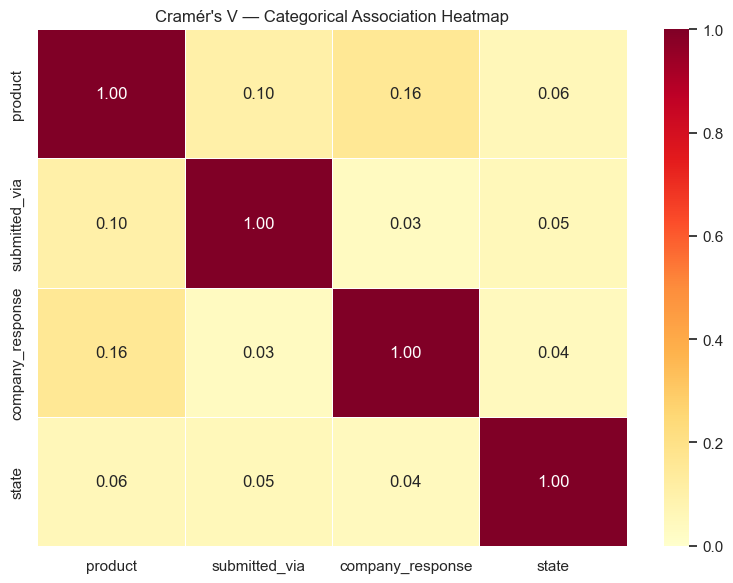

In [ ]:
cat_subset = ['product', 'submitted_via', 'company_response', 'state']
cat_subset = [c for c in cat_subset if c in df.columns]

if len(cat_subset) > 1:
    cv_matrix = pd.DataFrame(index=cat_subset, columns=cat_subset, dtype=float)
    for c1 in cat_subset:
        for c2 in cat_subset:
            if c1 == c2:
                cv_matrix.loc[c1, c2] = 1.0
            else:
                tmp = df[[c1, c2]].dropna()
                cv_matrix.loc[c1, c2] = cramers_v(tmp[c1], tmp[c2]) if len(tmp) > 10 else np.nan

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cv_matrix.astype(float), annot=True, fmt='.2f',
                cmap='YlOrRd', ax=ax, linewidths=0.5, vmin=0, vmax=1)
    ax.set_title("Cramér's V — Categorical Association Heatmap")
    plt.tight_layout()
    plt.show()

#### 4.2.3 Bivariate with time 

/var/folders/bf/1sjsjmcd4_j9q1b0h29g2crr0000gn/T/ipykernel_45242/1507389022.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts = df.set_index('date_received').resample('M').size().rename('n_complaints')


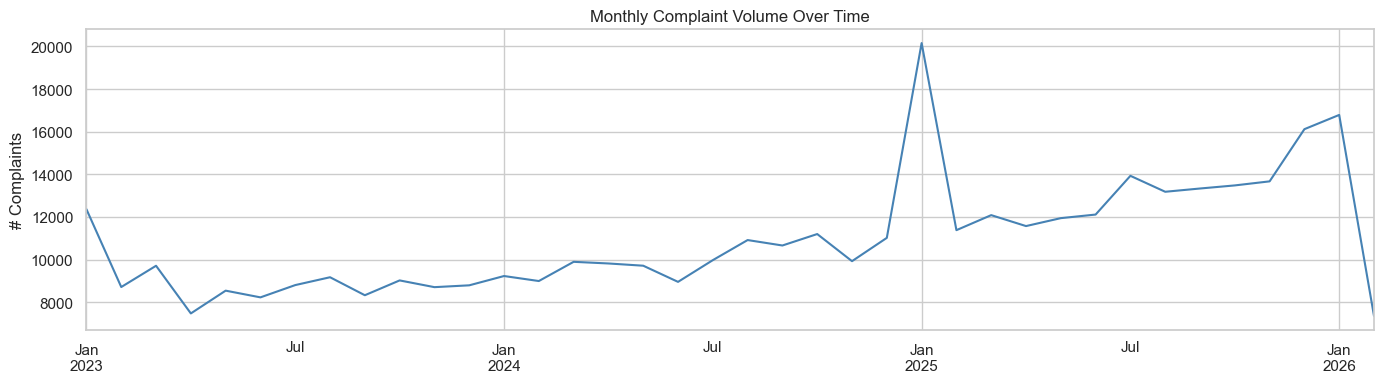

/var/folders/bf/1sjsjmcd4_j9q1b0h29g2crr0000gn/T/ipykernel_45242/1507389022.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby([pd.Grouper(freq='M'), 'product'])


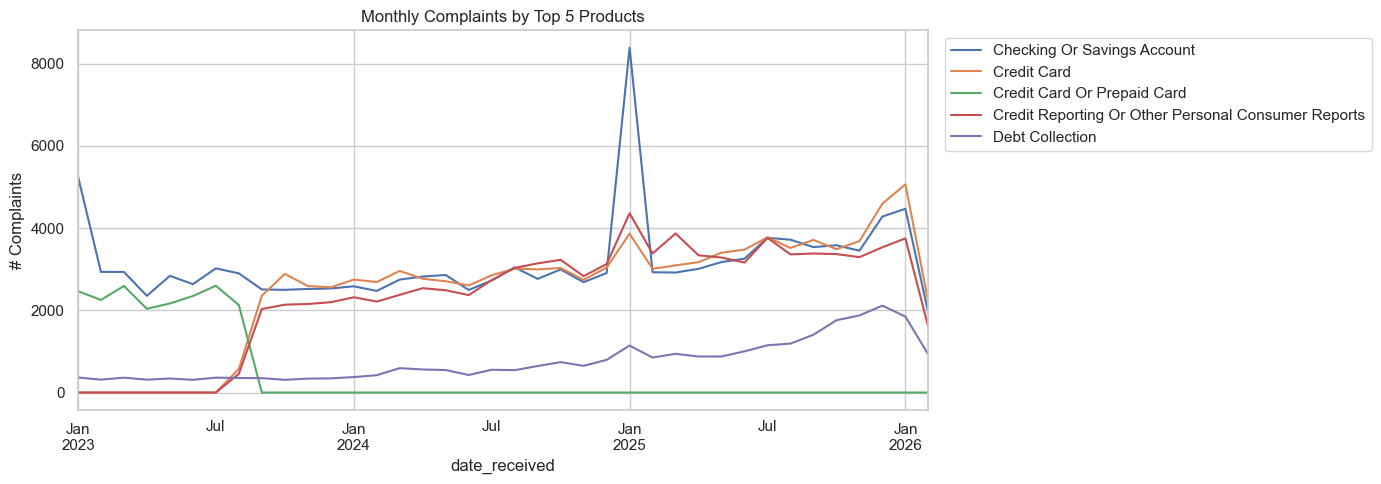

In [227]:
if 'date_received' in df.columns:
    ts = df.set_index('date_received').resample('M').size().rename('n_complaints')
    fig, ax = plt.subplots(figsize=(14, 4))
    ts.plot(ax=ax, color='steelblue')
    ax.set_title('Monthly Complaint Volume Over Time')
    ax.set_ylabel('# Complaints')
    ax.set_xlabel('')
    plt.tight_layout()
    plt.show()

    # Breakdown by top products over time
    if 'product' in df.columns:
        top_products = df['product'].value_counts().head(5).index
        ts_prod = (
            df[df['product'].isin(top_products)]
              .set_index('date_received')
              .groupby([pd.Grouper(freq='M'), 'product'])
              .size()
              .unstack('product', fill_value=0)
        )
        fig, ax = plt.subplots(figsize=(14, 5))
        ts_prod.plot(ax=ax)
        ax.set_title('Monthly Complaints by Top 5 Products')
        ax.set_ylabel('# Complaints')
        ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

* Recognize the spike in Jan 2025, then then breakdown analysis was conducted to see which complaints contribute the most

In [246]:
def breakdown_analysis(df, col, ax):
    top_product = df[col].value_counts().head(10)
    top_product.plot.barh(ax=ax, color='steelblue', edgecolor='white')
    ax.invert_yaxis()
    ax.set_title('Top 10 Products — Jan 2025')
    ax.set_xlabel('# Complaints')
    for p in ax.patches:
        ax.annotate(f'{int(p.get_width()):,}',
                        (p.get_width(), p.get_y() + p.get_height() / 2),
                        ha='left', va='center', fontsize=9)

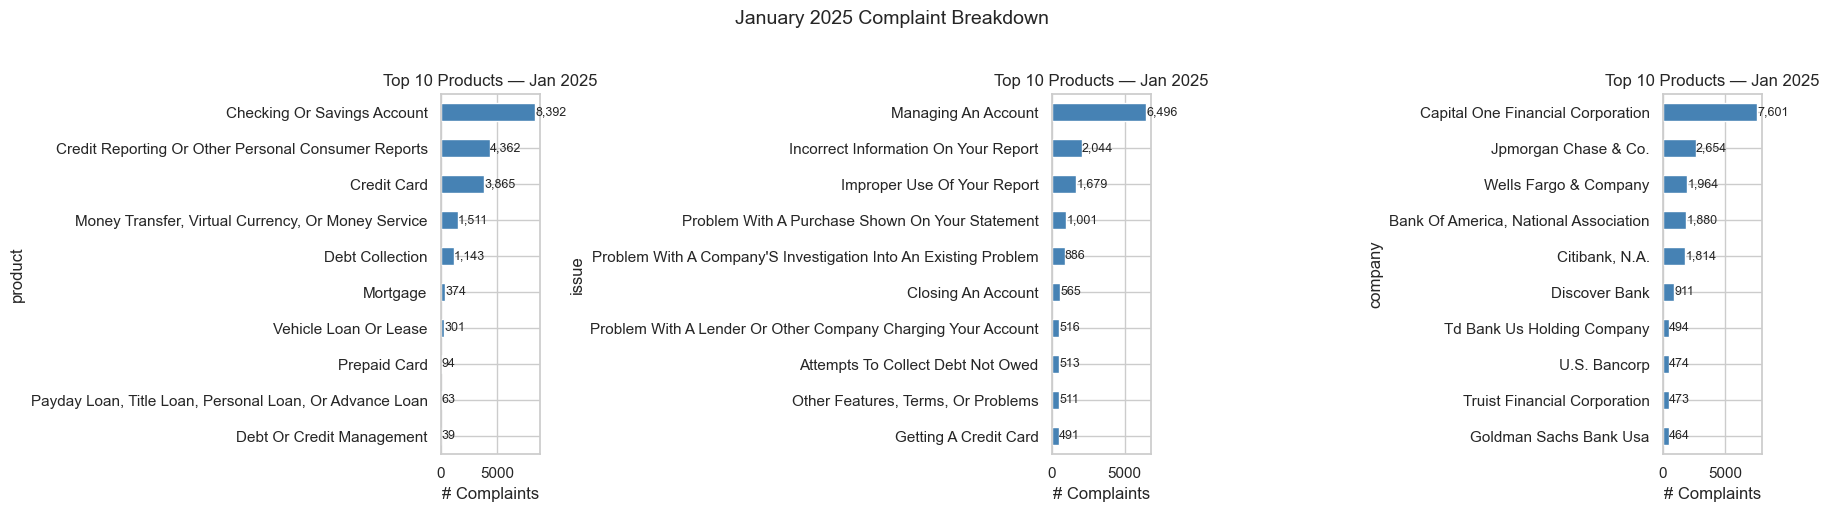

In [247]:
jan_df = df[
    (df['date_received'].dt.year == 2025) &
    (df['date_received'].dt.month == 1)
].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

breakdown_analysis(jan_df, 'product', axes[0])
breakdown_analysis(jan_df, 'issue', axes[1])
breakdown_analysis(jan_df, 'company', axes[2])

plt.suptitle('January 2025 Complaint Breakdown', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 4.3 Multivariate

#### 4.3.1 days_to_response by Product

In [ ]:
def dot_charts(col1, col2):
    if all(c in df.columns for c in [col1, col2]):
        
        top10 = df[col2].value_counts().head(10).index
        plot_df = df[df[col2].isin(top10)].copy()

        fig, ax = plt.subplots(figsize=(13, 5))

        sns.boxplot(
            data=plot_df,
            x='product',
            y='days_to_response',
            ax=ax
        )

        ax.set_title('Days to Response by Product (Top 10 Products)')
        ax.set_xlabel('Product')
        ax.set_ylabel('Days to Response')

        plt.xticks(rotation=20, ha='right')
        plt.tight_layout()
        plt.show()

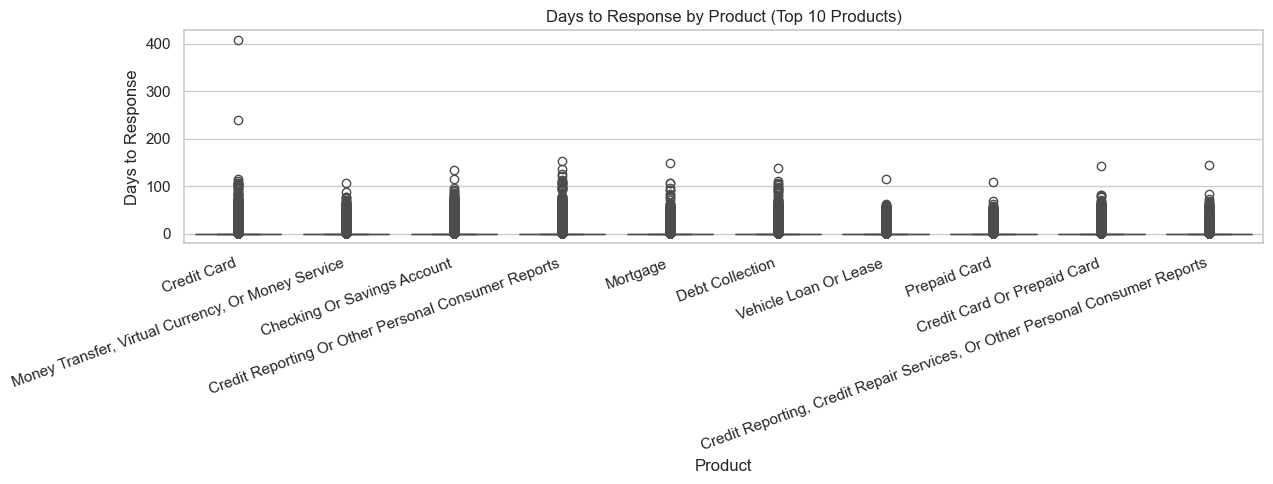

In [245]:
dot_charts('days_to_response', 'product')

#### 4.3.2 Complaint Heatmap: State × Product

* descending order

In [ ]:
def heatmap(col1, col2):
    if all(c in df.columns for c in [col1, col2]):

        top_col1 = df[col1].value_counts().head(10).index
        top_col2 = df[col2].value_counts().head(8).index

        pivot = (
            df[df[col1].isin(top_col1) & df[col2].isin(top_col2)]
            .groupby([col1, col2])
            .size()
            .unstack(fill_value=0)
        )
        # Sort rows and columns descending
        pivot = pivot.sort_index(ascending=False)
        pivot = pivot.sort_index(axis=1, ascending=False)
        fig, ax = plt.subplots(figsize=(14, 6))

        sns.heatmap(
            pivot,
            cmap='YlOrRd',
            annot=True,
            fmt='d',
            linewidths=0.3,
            ax=ax
        )

        ax.set_title(f'Complaint Count: {col1} × {col2}')
        plt.tight_layout()
        plt.show()

/var/folders/bf/1sjsjmcd4_j9q1b0h29g2crr0000gn/T/ipykernel_45242/1703675057.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


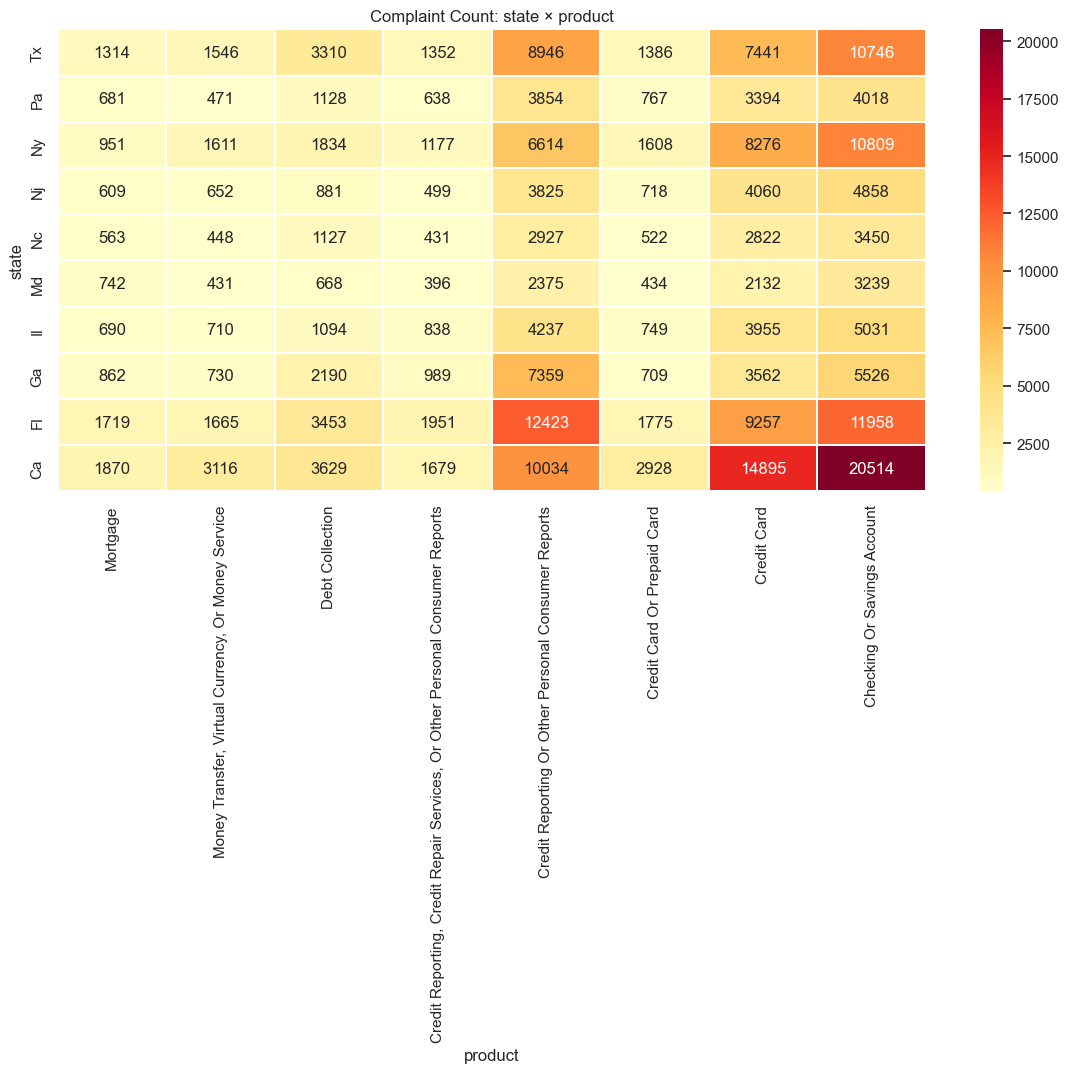

In [239]:
heatmap('state', 'product')

/var/folders/bf/1sjsjmcd4_j9q1b0h29g2crr0000gn/T/ipykernel_45242/1703675057.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


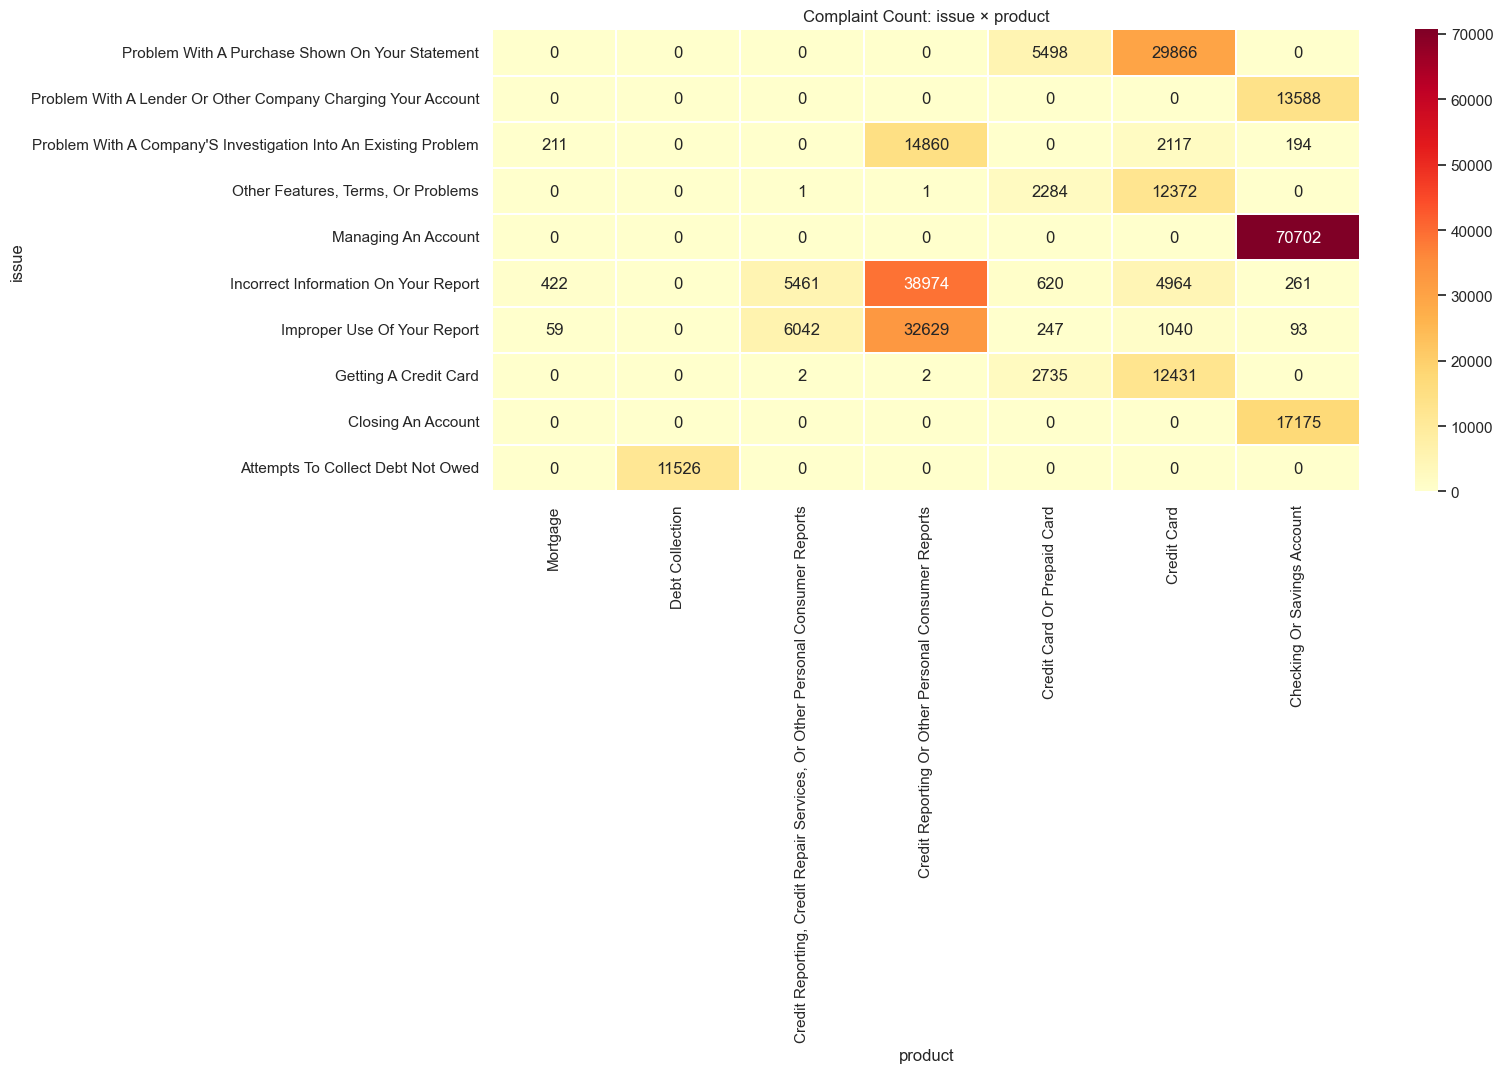

In [240]:
heatmap('issue', 'product')

# Clean dataframe summary

In [230]:
print("=== Final Cleaned DataFrame ===")
print(f"  Shape          : {df.shape}")
print(f"  Memory usage   : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"  Date range     : {df['date_received'].min()} → {df['date_received'].max()}" if 'date_received' in df.columns else '')
print(f"  Total nulls    : {df.isnull().sum().sum():,}")
print(f"  Duplicate rows : {df.duplicated().sum()}")

=== Final Cleaned DataFrame ===
  Shape          : (415254, 23)
  Memory usage   : 640.0 MB
  Date range     : 2023-01-01 00:00:00 → 2026-02-26 00:00:00
  Total nulls    : 1,039,693
  Duplicate rows : 0
